# Level 2 – Data Analysis Internship (Cognifyz)

## Overview
This notebook contains Level 2 tasks of the Cognifyz Data Analysis Internship.
The focus of Level 2 is deeper analytical exploration, including rating behavior,
cuisine combinations, geographic distribution, and restaurant chains.

The analysis aims to extract actionable insights using statistical aggregation
and visualization techniques.

## Dataset Loading and Initial Inspection
The dataset is loaded and inspected to ensure consistency and usability
for Level 2 analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Level 2 – Task 1: Restaurant Ratings

### Objective
This task focuses on analyzing customer rating behavior by:
- Examining the distribution of aggregate restaurant ratings
- Identifying the most common rating range
- Calculating the average number of votes received by restaurants

This helps assess overall customer satisfaction and engagement.

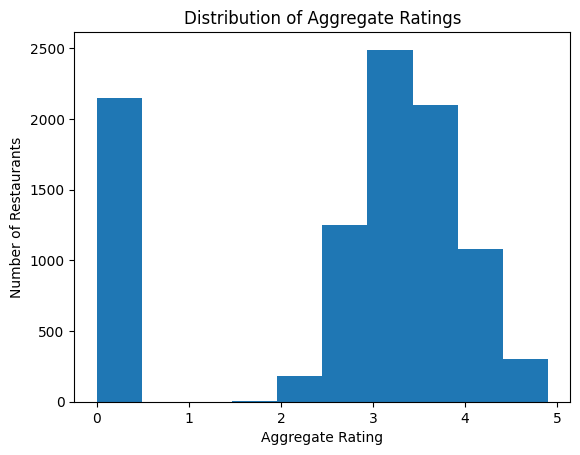

In [2]:
plt.hist(df['Aggregate rating'], bins=10)
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Aggregate Ratings")
plt.show()


In [3]:
avg_votes = df['Votes'].mean()
avg_votes

np.float64(156.909747670401)

### Insights
Most restaurants fall within a mid-range rating band, indicating generally
moderate customer satisfaction across the dataset.
The average number of votes suggests that only a subset of restaurants
receives high customer engagement.

## Level 2 – Task 2: Cuisine Combination Analysis

### Objective
The objective of this task is to:
- Identify the most common combinations of cuisines offered by restaurants
- Analyze whether certain cuisine combinations tend to have higher ratings

This analysis highlights customer preferences for multi-cuisine offerings.

In [4]:
cuisine_combinations = df['Cuisines'].dropna().value_counts().head(10)
cuisine_combinations

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

In [5]:
combo_ratings = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False).head(10)
combo_ratings

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64

### Insights
Certain cuisine combinations appear more frequently, indicating strong demand
for multi-cuisine dining experiences.
Some combinations also show higher average ratings, suggesting that variety
positively influences customer satisfaction.

## Level 2 – Task 3: Geographic Analysis

### Objective
This task aims to:
- Plot restaurant locations using latitude and longitude
- Identify geographical patterns or clustering of restaurants

The goal is to understand spatial concentration of restaurants.

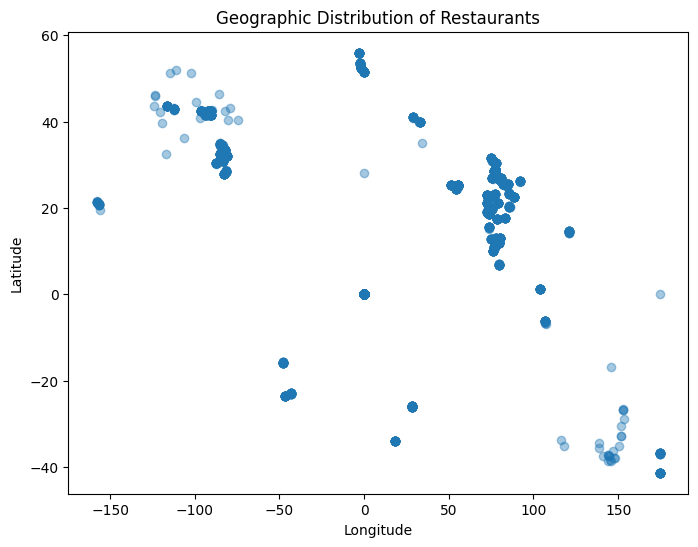

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.4)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Restaurants")
plt.show()

### Insights
The geographic visualization reveals noticeable clustering of restaurants
in specific regions, indicating urban concentration.
This suggests higher business activity and customer density in these areas.

## Level 2 – Task 4: Restaurant Chains

### Objective
This task focuses on:
- Identifying restaurant chains present in the dataset
- Analyzing their ratings and popularity based on customer votes

This helps compare brand-driven restaurants versus independent outlets.

In [7]:
chain_counts = df['Restaurant Name'].value_counts()
chains = chain_counts[chain_counts > 1].head(10)
chains

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

In [ ]:
chain_ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean().sort_values(ascending=False).head(10)
chain_ratings

### Insights
Several restaurant chains appear multiple times, confirming brand presence.
Well-established chains generally maintain consistent ratings, suggesting
standardized quality and customer trust.


## Level 2 – Final Summary

Level 2 analysis provided deeper insights into restaurant ratings, cuisine
combinations, geographic clustering, and chain performance.

Key observations include consistent mid-range ratings, customer preference
for multi-cuisine offerings, strong urban restaurant clustering, and stable
performance of restaurant chains. These insights help understand customer
behavior and market structure in the restaurant industry.